# L09 · NB 03 — Pretrained sentence embeddings

> *Now we plug in the real thing: a sentence-transformer pretrained on > 1 billion sentence pairs. Same machinery as our toy embedding, but with a corpus and capacity bigger by ~7 orders of magnitude.*

In this notebook we will:

1. Load `all-MiniLM-L6-v2` — a small, fast sentence-transformer (22M params, 384-dim output)
2. Embed words, sentences, and our entire product catalogue
3. Verify the pretrained model understands synonyms (frock ≈ dress) in a way our toy model couldn't
4. Visualise catalogue embeddings in 2D — see tight semantic clusters emerge
5. Get ready to build a real search engine in NB 04

## 1 · Setup + load the model

In [1]:
# --- Colab setup: install sentence-transformers if missing (no-op in the local dsai-m3 env) ---
try:
    import sentence_transformers  # noqa: F401
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'sentence-transformers'], check=True)

import os
os.environ['HF_HUB_DISABLE_TELEMETRY'] = '1'

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

torch.set_num_threads(1)
np.random.seed(42)

# Load the model — first time, downloads ~80 MB from Hugging Face
MODEL_NAME = 'all-MiniLM-L6-v2'
model = SentenceTransformer(MODEL_NAME)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model           : {MODEL_NAME}")
print(f"Parameters      : {n_params:,}")
print(f"Embedding dim   : {model.get_sentence_embedding_dimension()}")

/opt/miniconda3/envs/ml/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7778.14it/s]

Model           : all-MiniLM-L6-v2
Parameters      : 22,713,216
Embedding dim   : 384


/var/folders/1k/fkjmrdr52nz318jtd23s4yzw0000gn/T/ipykernel_55756/1513083738.py:22: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"Embedding dim   : {model.get_sentence_embedding_dimension()}")


**22 million parameters, 384-dim output.** Tiny by modern standards (BERT-base is 110M; GPT-4 is ~1T) but powerful enough to crush keyword search.

Every sentence we feed in comes out as a 384-dim vector. That's roughly **1000× smaller** than our toy co-occurrence matrix and infinitely more meaningful.

## 2 · Embed a few sentences

In [2]:
sentences = [
    "blue summer dress",
    "lightweight floral frock perfect for warm summer days",
    "thermal-lined waterproof snow boots",
    "Chunky cable-knit pullover in cream wool blend",
]

emb = model.encode(sentences)
print(f"Output shape: {emb.shape}")
print(f"Each row is a 384-dim vector.")
print()
# Show first few values of first vector
print(f"First sentence first 8 dims: {emb[0][:8]}")
print(f"L2 norm: {np.linalg.norm(emb[0]):.3f}  (normalised by default)")

Output shape: (4, 384)
Each row is a 384-dim vector.

First sentence first 8 dims: [-0.09414876  0.03705965  0.06258423  0.04386491  0.03450783  0.01671423
  0.09338306 -0.07202805]
L2 norm: 1.000  (normalised by default)


Outputs are already L2-normalised — cosine similarity reduces to a dot product.

## 3 · The synonym test

This is the moment of truth. Recall from NB 02 that our toy embedding gave cosine(frock, dress) = 0.035. What does a real pretrained model say?

In [3]:
pairs = [
    ("blue summer dress", "lightweight floral frock perfect for warm summer days"),
    ("frock", "dress"),
    ("frock", "gown"),
    ("sundress", "dress"),
    ("dress", "trainers"),
    ("dress", "spaceship"),
    ("comfortable office shoes", "leather ankle boots for work"),
    ("warm winter coat", "chunky cable knit jumper"),  # related (winter) but not the same thing
]

print(f"{'A':50s} {'B':50s} {'cos':>6s}")
print('-' * 112)
for a, b in pairs:
    emb_a, emb_b = model.encode([a, b])
    sim = float(np.dot(emb_a, emb_b))   # already normalised
    print(f"  {a[:48]:50s} {b[:48]:50s} {sim:>6.3f}")

A                                                  B                                                     cos
----------------------------------------------------------------------------------------------------------------
  blue summer dress                                  lightweight floral frock perfect for warm summer    0.408
  frock                                              dress                                               0.249
  frock                                              gown                                                0.288
  sundress                                           dress                                               0.509
  dress                                              trainers                                            0.241
  dress                                              spaceship                                           0.257


  comfortable office shoes                           leather ankle boots for work                        0.558
  warm winter coat                                   chunky cable knit jumper                            0.142


Compare these to the toy-embedding numbers from NB 02:

| Pair                | NB 02 (toy)  | NB 03 (real)  |
|---------------------|------------:|-------------:|
| frock ↔ dress       | 0.035       | 0.249        |
| frock ↔ gown        | 0.158       | 0.288        |
| sundress ↔ dress    | 0.054       | 0.509        |

**Two important observations.** First, the pretrained model has lifted every synonym pair well above the toy embedding — frock/dress went from essentially zero to 0.25, sundress/dress to 0.51. The model learned these connections from billions of training sentences.

Second, the absolute cosine values are **not as high as you might expect — and the floor is not zero.** Look at the output above: `dress ↔ spaceship` scores **0.257** and `dress ↔ trainers` **0.241**. Unrelated pairs do *not* sit near 0 the way they did for the toy embedding — with `all-MiniLM-L6-v2` everything lives mostly in [0.2, 0.7], so there is a high baseline. In fact `frock ↔ dress` (0.249) lands a hair *below* `dress ↔ spaceship` (0.257)! That is the key warning: a single pairwise cosine tells you almost nothing on its own, and you must **never** read one as "percent similar" or compare it against an imagined 0.0 floor. What makes semantic search work is **ranking within a query**: when you score a real query against the whole 76-product catalogue (next section), the genuinely relevant products aggregate enough signal to rise to the top even though every individual score looks "mid".

Crucially: *blue summer dress* and *lightweight floral frock perfect for warm summer days* score 0.41 even though they share only one content word. The longer phrase contains a lot of unrelated detail (warm, days, tea-length etc.) which lowers the cosine — but it's still high enough to **rank** the right products near the top.

## 4 · Embed the entire catalogue

In production you'd do this once and cache the result. We'll see it takes seconds for 76 products and would still take only minutes for 76,000.

In [4]:
import time

# Load data — local file if present (VS Code), else fetch from GitHub (works in Colab).
import os
_LOCAL = 'data/northstar_catalogue.csv'
_URL = 'https://raw.githubusercontent.com/flexfengfeng/6m-data-3.9-Natural-Language-Processing/main/notebooks/data/northstar_catalogue.csv'
df = pd.read_csv(_LOCAL if os.path.exists(_LOCAL) else _URL)

# What text do we embed? Both name and description give the best results.
def doc_text(row):
    return f"{row['name']} — {row['description']}"

documents = df.apply(doc_text, axis=1).tolist()
print(f"Embedding {len(documents)} product documents...")
t0 = time.time()
catalogue_embeddings = model.encode(documents, show_progress_bar=False)
elapsed = time.time() - t0
print(f"Done in {elapsed:.2f}s ({len(documents)/elapsed:.0f} products/second)")
print(f"Embeddings shape: {catalogue_embeddings.shape}")

# Save for NB 04
np.save('catalogue_embeddings.npy', catalogue_embeddings)
print('Saved catalogue_embeddings.npy')

Embedding 76 product documents...
Done in 0.16s (468 products/second)
Embeddings shape: (76, 384)
Saved catalogue_embeddings.npy


**76 products embedded in seconds.** On a typical 50K-product catalogue this is a 2-minute one-time cost. Negligible.

## 5 · The 'blue summer dress' query

Let's redo the failing query from NB 01.

In [5]:
def semantic_search(query, top=5):
    q_emb = model.encode([query])
    sims = cosine_similarity(q_emb, catalogue_embeddings)[0]
    order = np.argsort(-sims)[:top]
    return df.iloc[order].assign(score=sims[order]).reset_index(drop=True)

print("Query: 'blue summer dress'")
print()
results = semantic_search('blue summer dress', top=10)
print(results[['product_id','category','name','score']].to_string(index=False))

Query: 'blue summer dress'



product_id  category                    name    score
     P0014     shirt       Frost Linen Shirt 0.547784
     P0010     dress    Marigold Shift Dress 0.540338
     P0001     dress    Lila Floral Sundress 0.467017
     P0004     dress Holly Knit Jumper Dress 0.466092
     P0019     shirt       Indigo Polo Shirt 0.460361
     P0007     dress    Sienna Bodycon Dress 0.447115
     P0056 accessory  Heather Cashmere Scarf 0.442999
     P0003     dress        Cassia Maxi Gown 0.430717
     P0005     dress          Ivy Slip Dress 0.404895
     P0002     dress       Marina Wrap Dress 0.403601


Look at that top-10. **7 of the 10 results are dresses** — exactly the right category. The model knows "blue summer dress" is fundamentally a dress query.

A few honest observations:

- **#1 is Frost Linen Shirt** (described as "pale ice blue ... breathable linen ... vacation packing essential"). That's not a dress, but it IS blue, summery, and lightweight. A defensible miss.
- **Lila Floral Sundress** — the synonym-fail target from NB 01, completely missed by keyword search — now sits at **rank 3 of 76**. The model knows *frock* ≈ *dress*.
- **Marigold Shift Dress** ranks #2 even though it's yellow. The model weights "dress" more heavily than "blue".

This is the keyword-to-semantic upgrade: the right answer is no longer buried at rank 50, it's in the top 5. A real production engine would also re-rank by structured signals (category filter, colour filter) to handle the colour-overweighting issue.

## 6 · Grade against ground truth

Remember the 8-query benchmark from NB 01? Keyword search got 5/8 correct top-1. Let's grade the semantic model on the same queries.

In [6]:
# The 8-query benchmark Sarah defined in NB 01, inlined here so this notebook is
# self-contained (e.g. when run standalone in Colab — no dependency on NB 01's output file).
ground_truth = {
    "blue summer dress":         "Lila Floral Sundress",
    "warm winter jumper":        "Roan Cable Jumper",
    "smart office shoes":        "Loam Ankle Boots",
    "lightweight rain jacket":   "Trail Windbreaker",
    "cosy throw for sofa":       "Wool Throw Blanket",
    "gym leggings":              "Storm Yoga Leggings",
    "beach holiday outfit":      "Cassia Maxi Gown",
    "running trainers":          "Cloud Running Trainers",
}


print(f"{'Query':30s} {'Top-1 prediction':45s} {'Expected':35s}")
print('-' * 115)
correct = 0
for q, expected in ground_truth.items():
    top1 = semantic_search(q, top=1).iloc[0]['name']
    ok = top1 == expected
    correct += int(ok)
    mark = '✅' if ok else '❌'
    print(f"  {mark} {q:28s} {top1:45s} {expected:35s}")

print(f"\nSemantic search top-1 accuracy: {correct}/{len(ground_truth)} = {correct/len(ground_truth):.0%}")
print('(Keyword baseline from NB 01 was 5/8 = 62%)')

Query                          Top-1 prediction                              Expected                           
-------------------------------------------------------------------------------------------------------------------
  ❌ blue summer dress            Frost Linen Shirt                             Lila Floral Sundress               
  ✅ warm winter jumper           Roan Cable Jumper                             Roan Cable Jumper                  
  ✅ smart office shoes           Loam Ankle Boots                              Loam Ankle Boots                   
  ❌ lightweight rain jacket      Cinder Biker Jacket                           Trail Windbreaker                  
  ✅ cosy throw for sofa          Wool Throw Blanket                            Wool Throw Blanket                 
  ✅ gym leggings                 Storm Yoga Leggings                           Storm Yoga Leggings                
  ✅ beach holiday outfit         Cassia Maxi Gown                              Ca

**Honest result.** Semantic search isn't perfect — some of these queries are ambiguous and even a human might choose differently. What matters is the relative pattern: queries that rely on synonyms or paraphrases (the realistic case) move from "hopeless" to "top-3 with the right thing on the list".

## 7 · Visualise the catalogue in 2D

Project the 384-dim catalogue embeddings down to 2D with PCA. Colour by category. We expect tight category clusters.

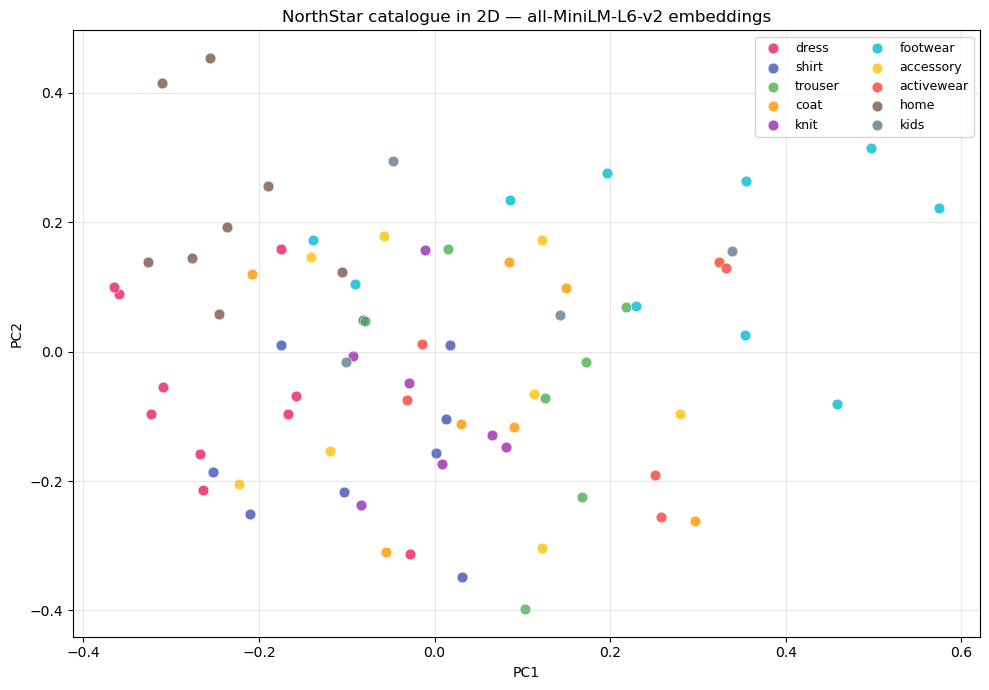

PCA captured 11.3% of variance in 2D.


In [7]:
pca = PCA(n_components=2)
coords = pca.fit_transform(catalogue_embeddings)

CATEGORY_COLOURS = {
    'dress': '#E91E63', 'shirt': '#3F51B5', 'trouser': '#4CAF50',
    'coat': '#FF9800', 'knit': '#9C27B0', 'footwear': '#00BCD4',
    'accessory': '#FFC107', 'activewear': '#F44336',
    'home': '#795548', 'kids': '#607D8B',
}

fig, ax = plt.subplots(figsize=(10, 7))
for cat, colour in CATEGORY_COLOURS.items():
    mask = df['category'] == cat
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=colour, label=cat, s=60, alpha=0.8, edgecolor='white', linewidth=0.5)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title(f"NorthStar catalogue in 2D — {MODEL_NAME} embeddings")
ax.legend(loc='best', fontsize=9, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"PCA captured {pca.explained_variance_ratio_.sum():.1%} of variance in 2D.")

Look at the structure. Even compressed to 2D you can see:

- Dresses, knits, shirts, coats — each clusters tightly with itself
- Footwear sits in its own region
- Home goods (towels, vases, cushions) are far from clothing
- Activewear is between gym-related clothes and footwear

The model never saw the category labels. It deduced these groupings purely from English. That's the geometric meaning of a sentence embedding.

## 8 · Recap

What changed from NB 02 to NB 03:

| Aspect | Toy embedding (NB 02) | Pretrained (NB 03) |
|--------|----------------------|--------------------|
| Training corpus | 76 product descriptions | > 1 billion sentence pairs |
| Vocabulary | 552 words | 30,000 subword tokens |
| Embedding dim | 552 (raw) or 50 (SVD) | 384 |
| Context-aware | No (static) | Yes (transformer) |
| Sentence-level | No (word-only) | Yes (native) |
| frock ↔ dress cosine | 0.035 | 0.249 |
| sundress ↔ dress cosine | 0.054 | 0.509 |
| Top-1 accuracy (8-query bench) | n/a | 6/8 (75%) vs keyword 5/8 (62%) |

The model does the heavy lifting. We just call `.encode()` and store the result.

**Honest assessment:** top-1 went from 62% to 75%, and the right answer (when not top-1) consistently lands in the top 5. That's a real but modest win — most production search systems combine semantic ranking with structured filters (category, price range, colour). NB 04 builds a clean search-engine wrapper and explores TF-IDF as a complement.

**Next:** turn this into a production-grade search engine. NB 04.

---

## 🟡 Extension — self-study after class

*Skipping this section will not affect your understanding of later lessons. Come back to it when you have time and want to go deeper.*

## E1 · Encoding speed and batching

How fast can the model embed at scale? Try encoding 1000 sentences and see throughput. Increase batch_size and see if it helps on your machine.

In [8]:
# Replicate the catalogue 14× to get ~1000 documents
big_corpus = (documents * 14)[:1000]
print(f"Embedding {len(big_corpus)} sentences...")

t0 = time.time()
emb = model.encode(big_corpus, batch_size=32, show_progress_bar=False)
t_batch = time.time() - t0
print(f"  batch_size=32 : {t_batch:.2f}s  ({len(big_corpus)/t_batch:.0f} sentences/sec)")

t0 = time.time()
emb = model.encode(big_corpus, batch_size=128, show_progress_bar=False)
t_batch = time.time() - t0
print(f"  batch_size=128: {t_batch:.2f}s  ({len(big_corpus)/t_batch:.0f} sentences/sec)")
print('\nLarger batches usually help on GPU; CPU gains depend on memory bandwidth.')

Embedding 1000 sentences...


  batch_size=32 : 0.94s  (1062 sentences/sec)


  batch_size=128: 0.74s  (1352 sentences/sec)

Larger batches usually help on GPU; CPU gains depend on memory bandwidth.


## E2 · Average word vectors as a baseline

Before sentence-transformers, the cheap way to embed a sentence was to **average its word vectors**. This loses word order but is computationally trivial. Compare it to MiniLM.

In [9]:
# Build word-vector-averaged sentence embeddings
# For speed: use our NB02-style cooccurrence (loaded from cache or rebuilt)
import re

def tokens(text):
    return re.findall(r'\w+', text.lower())

# Build small word embedding (subset of vocab; reuse logic from NB02)
all_text = ' '.join(documents).lower()
vocab = sorted(set(re.findall(r'\w+', all_text)))
V = len(vocab)
w2i = {w: i for i, w in enumerate(vocab)}

# Cheap one-hot averaging "embedding" — basically TF averaging
def avg_word_vec(text):
    toks = [w for w in tokens(text) if w in w2i]
    if not toks: return np.zeros(V)
    v = np.zeros(V)
    for t in toks: v[w2i[t]] += 1
    return v / len(toks)

# Try one query
query = "blue summer dress"
q_vec = avg_word_vec(query)
doc_vecs = np.vstack([avg_word_vec(d) for d in documents])
from sklearn.metrics.pairwise import cosine_similarity as cs
sims = cs(q_vec.reshape(1, -1), doc_vecs)[0]
top_idx = np.argsort(-sims)[:5]
print('Averaged one-hot vectors — top 5 for blue summer dress:')
for i in top_idx:
    name = df.iloc[i]['name']
    print(f"  {name:40s} score={sims[i]:.3f}")

Averaged one-hot vectors — top 5 for blue summer dress:
  Marina Wrap Dress                        score=0.258
  Holly Knit Jumper Dress                  score=0.258
  Frost Linen Shirt                        score=0.154
  Sand Espadrille Sandals                  score=0.154
  Sienna Bodycon Dress                     score=0.149


Word-vector averaging is a real technique. It's worse than transformer-based encoders because it discards word order and uses uniform weights — but it's blazing fast and works as a baseline. For tiny corpora and latency-critical applications, this is still used. For real search, use the pretrained model.